## This is a sample Machine Learning project that exemplifies how to proceed Linear Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Networkx, Pingouin, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
from scipy.stats import boxcox
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from statstests.process import stepwise
import networkx as nx
import pingouin as pg
import seaborn as sns
import plotly.graph_objects as go
import os
import plotly.io as pio
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - saeb = f(performance, state). Multiple Linear Regression.

This is another use-case for Generalized Linear Models (GLMs), in this case, of type Multiple Linear Regression (MLR). Here, we have a dataset that basically describes some variables associated with the education quality program called SAEB, at Brazil. The "saeb" is the raw average result (grade), for each basic education school at Brazil, of a national-level test applied to a sample of each school's elementary and high-education students, in Math and Language disciplines. This is the dependent variable we wanna regress on other variables, that is, the average "performance" of students (on other education quality metrics, as approval, repetition and dropout rates) and the geography (state). The aim of this project is to show how to diagnose and correct Heteroskedasticity, using Breusch–Pagan test, in order to have a regression model that can be trustful in terms of significance and predictiveness - which includes being Homoskedastic. We'll see it's crucial for the quality of our model, as a low multicollinearity and, in part, residuals normality (not mandatory) and also a good R2. For SLR and other MLR advanced topics, including shapiro-francia and box-cox - for residuals normality - as well as tolerance and VIF - for multicollinearity diagnosis, check out other examples at this same project directory.

In [2]:
# reading and displaying our dataset
saeb_df = pd.read_csv('saeb.csv', delimiter=',', encoding="utf-8")
saeb_df

,state,city,code,school,network,saeb,performance
0,RO,Alta Floresta D'Oeste,11024666,EMEIEF BOA ESPERANCA,Municipal,5.331833,0.766092
1,RO,Alta Floresta D'Oeste,11024682,EEEF EURIDICE LOPES PEDROSO,Estadual,NaN,0.910890
2,RO,Alta Floresta D'Oeste,11024828,EMEIEF IZIDORO STEDILE,Municipal,5.432333,0.884658
3,RO,Alta Floresta D'Oeste,11024917,EMEIEF JOSE BASILIO DA GAMA,Municipal,NaN,NaN
4,RO,Alta Floresta D'Oeste,11024968,EEEFM JUSCELINO KUBITSCHEK DE OLIVEIRA,Estadual,5.568833,0.957629
...,...,...,...,...,...,...,...
43602,DF,Brasília,53068106,CEF 02 DO RIACHO FUNDO II,Estadual,5.458000,0.905575
43603,DF,Brasília,53068114,CEF 27 DE CEILANDIA,Estadual,4.895667,0.882728
43604,DF,Brasília,53068122,CEF 28 DE CEILANDIA,Estadual,5.191667,0.841983
43605,DF,Brasília,53068149,CEF 32 DE CEILANDIA,Estadual,5.157667,0.766156


In [3]:
saeb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43607 entries, 0 to 43606
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state        43607 non-null  str    
 1   city         43607 non-null  str    
 2   code         43607 non-null  int64  
 3   school       43607 non-null  str    
 4   network      43607 non-null  str    
 5   saeb         25538 non-null  float64
 6   performance  37324 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 2.3 MB


In [4]:
saeb_df.describe()

,code,saeb,performance
count,4.360700e+04,25538.000000,37324.000000
mean,3.112734e+07,5.047511,0.856967
std,9.956731e+06,0.753718,0.110447
min,1.100026e+07,2.053000,0.247282
25%,2.316996e+07,4.554542,0.791561
50%,3.108142e+07,5.069500,0.878536
75%,3.590717e+07,5.551458,0.944761
max,5.306821e+07,8.588000,1.000000


In [5]:
saeb_df["state"].value_counts().sort_index()

state
AC     204
AL     718
AM     972
AP     172
BA    3539
CE    2971
DF     217
ES     831
GO    1400
MA    2761
MG    4399
MS     643
MT     966
PA    2046
PB    1075
PE    1866
PI    1289
PR    1886
RJ    2310
RN     859
RO     468
RR     128
RS    3315
SC    1742
SE     562
SP    5753
TO     515
Name: count, dtype: int64

In [6]:
saeb_df["network"].value_counts().sort_index()

network
Estadual     20959
Federal         38
Municipal    22610
Name: count, dtype: int64

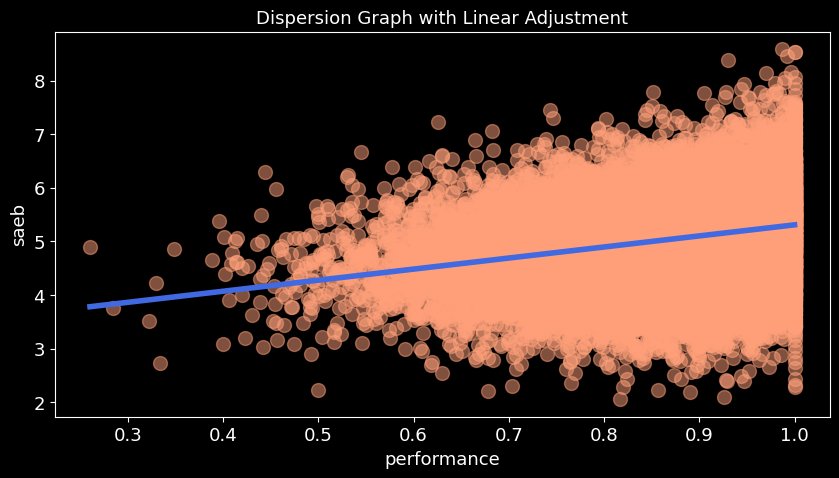

In [7]:
# plotting saeb x performance - observed values
plt.figure(figsize=(10,5))
sns.regplot(x='performance', y='saeb', data=saeb_df, marker='o',
            color='royalblue', ci=False,
            scatter_kws={'color':'lightsalmon', 'alpha':0.5, 's':100},
            line_kws={'linewidth': 4})
plt.title('Dispersion Graph with Linear Adjustment', fontsize=13)
plt.xlabel('performance', fontsize=13)
plt.ylabel('saeb', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

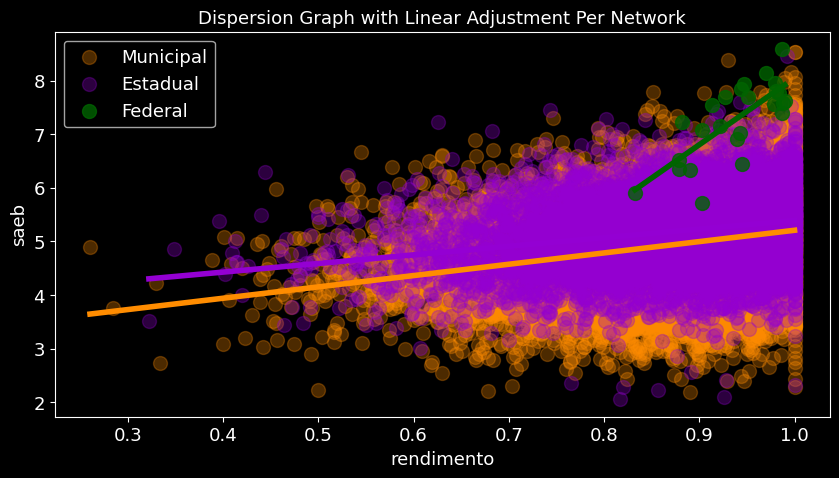

In [8]:
# plotting saeb x performance by network - observed values
df1 = saeb_df[saeb_df['network'] == 'Municipal']
df2 = saeb_df[saeb_df['network'] == 'Estadual']
df3 = saeb_df[saeb_df['network'] == 'Federal']
plt.figure(figsize=(10,5))
sns.regplot(x='performance', y='saeb', data=df1, marker='o', ci=False,
            scatter_kws={'color':'darkorange', 'alpha':0.3, 's':100},
            line_kws={'color':'darkorange', 'linewidth': 4}, label='Municipal')
sns.regplot(x='performance', y='saeb', data=df2, marker='o', ci=False,
            scatter_kws={'color':'darkviolet', 'alpha':0.3, 's':100},
            line_kws={'color':'darkviolet', 'linewidth': 4}, label='Estadual')
sns.regplot(x='performance', y='saeb', data=df3, marker='o', ci=False,
            scatter_kws={'color':'darkgreen', 'alpha':0.8, 's':100},
            line_kws={'color':'darkgreen', 'linewidth': 4}, label='Federal')
plt.title('Dispersion Graph with Linear Adjustment Per Network', fontsize=13)
plt.xlabel('rendimento', fontsize=13)
plt.ylabel('saeb', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.show()

In [9]:
# Estimating a first linear model
saeb_model = sm.OLS.from_formula('saeb ~ performance', saeb_df).fit()
saeb_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   saeb   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     2126.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:23:31   Log-Likelihood:                -27984.
No. Observations:               25530   AIC:                         5.597e+04
Df Residuals:                   25528   BIC:                         5.599e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.2425      0.039     82.277      0.000       3.165       3.320
performance     2.0665      0.045     46.111      0.000       1.979       2.154
==============================================================================
Omnibus:                      152.496   Durbin-Watson:                   1.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              201.269
Skew:                          -0.091   Prob(JB):                     1.97e-44
Kurtosis:                       3.395   Cond. No.                         17.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
# adding fitted values and residuals to the dataset df
saeb_df['fitted'] = saeb_model.fittedvalues
saeb_df['residuals'] = saeb_model.resid
saeb_df

,state,city,code,school,network,saeb,performance,fitted,residuals
0,RO,Alta Floresta D'Oeste,11024666,EMEIEF BOA ESPERANCA,Municipal,5.331833,0.766092,4.825556,0.506278
1,RO,Alta Floresta D'Oeste,11024682,EEEF EURIDICE LOPES PEDROSO,Estadual,NaN,0.910890,NaN,NaN
2,RO,Alta Floresta D'Oeste,11024828,EMEIEF IZIDORO STEDILE,Municipal,5.432333,0.884658,5.070567,0.361767
3,RO,Alta Floresta D'Oeste,11024917,EMEIEF JOSE BASILIO DA GAMA,Municipal,NaN,NaN,NaN,NaN
4,RO,Alta Floresta D'Oeste,11024968,EEEFM JUSCELINO KUBITSCHEK DE OLIVEIRA,Estadual,5.568833,0.957629,5.221359,0.347474
...,...,...,...,...,...,...,...,...,...
43602,DF,Brasília,53068106,CEF 02 DO RIACHO FUNDO II,Estadual,5.458000,0.905575,5.113792,0.344208
43603,DF,Brasília,53068114,CEF 27 DE CEILANDIA,Estadual,4.895667,0.882728,5.066579,-0.170913
43604,DF,Brasília,53068122,CEF 28 DE CEILANDIA,Estadual,5.191667,0.841983,4.982381,0.209286
43605,DF,Brasília,53068149,CEF 32 DE CEILANDIA,Estadual,5.157667,0.766156,4.825688,0.331978


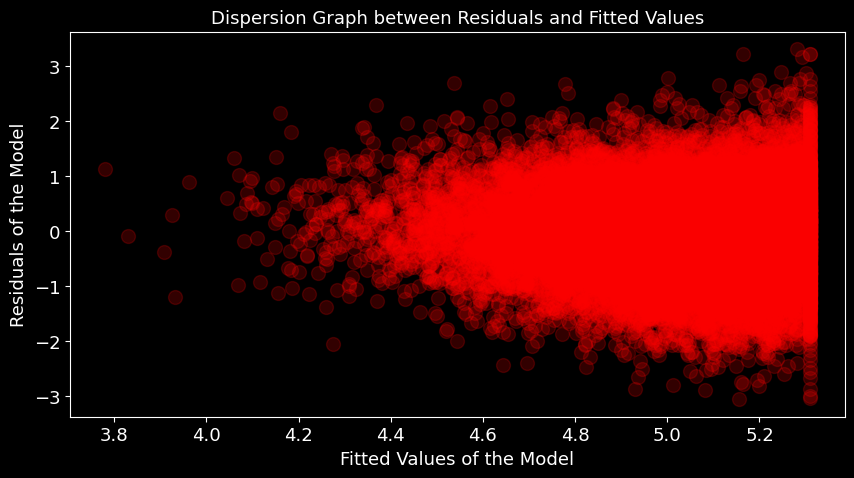

In [11]:
# plotting residuals x fitted values
plt.figure(figsize=(10,5))
sns.regplot(x='fitted', y='residuals', data=saeb_df,
            marker='o', fit_reg=False,
            scatter_kws={"color":'red', 'alpha':0.2, 's':100})
plt.title('Dispersion Graph between Residuals and Fitted Values', fontsize=13)
plt.xlabel('Fitted Values of the Model', fontsize=13)
plt.ylabel('Residuals of the Model', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

# Heteroskedasticity is a property of a regression model where the variance of the residuals (errors: Y - Ŷ) is not constant 
# across all levels of the predicted values.
# Observe at this first model - which is heteroskedastic, as confirmed by the Breusch-Pagan down below, the classic “funnel shape” 
# in the plot: residuals vs. fitted values.
# The spread (variance) of the residuals increases as the fitted values increase, it should be constant. The residuals should NOT
# explain any variable, including the target... and here it DOES explain, in part, assuming the role of missing and significant
# explicative variables - see down below what variable it is.
# The model’s residuals variance are not constant across predictions:
# - for lower fitted values → residuals are tighter (low variance)
# - for higher fitted values → residuals spread out more (high variance)
# See consequences for a heteroskedastic model below.

![heteroskedasticity_consequences.png](heteroskedasticity_consequences.png)

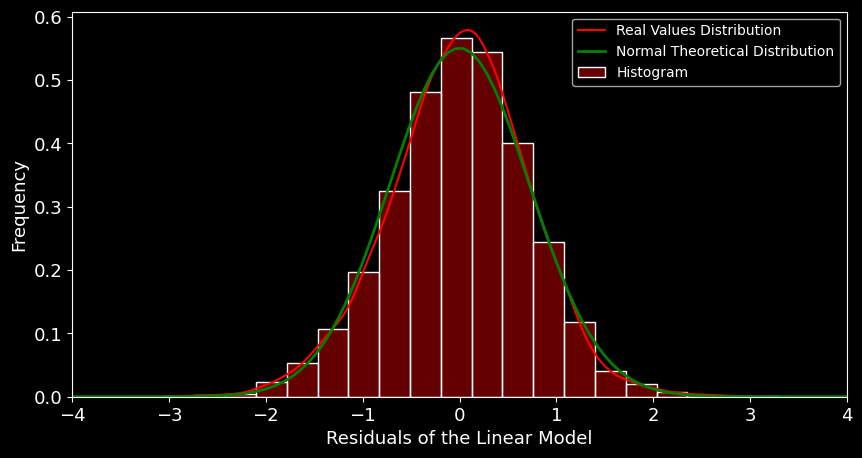

In [12]:
# Histogram of residuals distribution (from the model) x theoretical Normal distribution
# Kernel density estimation (KDE) - non-parametric form for estimation of density function probability of a certain variable

mu, sigma = norm.fit(saeb_model.resid)
plt.figure(figsize=(10,5))
sns.histplot(saeb_model.resid, bins=20, kde=True, stat="density",
             color='red', alpha=0.4)
plt.xlim(-4, 4)
x = np.linspace(-4, 4, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, color="green", linewidth=2)
plt.xlabel('Residuals of the Linear Model', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(['Real Values Distribution','Normal Theoretical Distribution','Histogram'],
           fontsize=10)
plt.show()

In [14]:
# Breusch-Pagan test for diagnosing heteroskedasticity

def breusch_pagan_test(model):
    df = pd.DataFrame({'yhat':model.fittedvalues,
                       'resid':model.resid})
    df['up'] = (np.square(df.resid))/np.sum(((np.square(df.resid))/df.shape[0]))
    model_aux = sm.OLS.from_formula('up ~ yhat', df).fit()
    anova_table = sm.stats.anova_lm(model_aux, typ=2)
    anova_table['sum_sq'] = anova_table['sum_sq']/2
    chisq = anova_table['sum_sq'].iloc[0]
    p_value = stats.chi2.pdf(chisq, 1)*2
    print(f"chisq: {chisq}")
    print(f"p-value: {p_value}")
    return float(chisq), float(p_value)

breusch_pagan_test = breusch_pagan_test(saeb_model)
chisq, p = breusch_pagan_test
alpha = 0.05 #significance level of the test
if p > alpha:
    print('H0 not rejected - Heteroskedasticity NOT present (Homoskedasticity)')
else:
	print('H0 rejected - Heteroskedasticity present')

# The presence of heteroskedasticity means, generally, the lack of a significant predictive variable at the model, from which 
# results the systematic correlation of residuals' variance with included model explicative variables or to their functions - 
# including their predicting functions (Ŷ).

# Possible causes for heteroskedasticity:
# - Scale effects (very common)
# - Model misspecification
# - Wrong functional form (e.g., should be log instead of linear)
# - Omitted variables (not always)
# - Measurement error
# - Intrinsic data structure

# In our case, the presence of heteroskedasticity on the initial model above (saeb ~ performance) may indicate the lack of 
# significant variables at our model, and, as a result, the residuals' variance substitutes such missing variables in explaining
# other variables, including the dependent variable. For fixing that, we could try adding the missing variable to the model and 
# redefine the model, running later the Breusch-Pagan again, on the new model... and check if heteroskedasticity was resolved.

chisq: 16.72070032595308
p-value: 4.5651903149394254e-05
H0 rejected - Heteroskedasticity present


In [15]:
# let's add the "state" explicative variable - but we gotta dummyzate it first, as it is a qualitative variable, and then we add
# its dummies instead

# dummyzing state qualitative variable, taking as reference variable the first one of the states, and excluding the state variable,
# substituting it by its dummies. Observe that all states are represented as dummy variables, except for AC, that, alphabetically, 
# is the first one that was taken as the dummy reference, that is, when all dummies are 0, then that school is from AC... otherwise
# the school is from the dummy whose respective state = 1.
saeb_df_dummies = pd.get_dummies(saeb_df, columns=['state'],
                                      dtype=int,
                                      drop_first=True)
print(saeb_df["state"].unique())
print(saeb_df_dummies.columns)
saeb_df_dummies

<StringArray>
['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO', 'MA', 'PI', 'CE', 'RN', 'PB', 'PE',
 'AL', 'SE', 'BA', 'MG', 'ES', 'RJ', 'SP', 'PR', 'SC', 'RS', 'MS', 'MT', 'GO',
 'DF']
Length: 27, dtype: str
Index(['city', 'code', 'school', 'network', 'saeb', 'performance', 'fitted',
       'residuals', 'state_AL', 'state_AM', 'state_AP', 'state_BA', 'state_CE',
       'state_DF', 'state_ES', 'state_GO', 'state_MA', 'state_MG', 'state_MS',
       'state_MT', 'state_PA', 'state_PB', 'state_PE', 'state_PI', 'state_PR',
       'state_RJ', 'state_RN', 'state_RO', 'state_RR', 'state_RS', 'state_SC',
       'state_SE', 'state_SP', 'state_TO'],
      dtype='str')


,city,code,school,network,saeb,performance,fitted,residuals,state_AL,state_AM,...,state_PR,state_RJ,state_RN,state_RO,state_RR,state_RS,state_SC,state_SE,state_SP,state_TO
0,Alta Floresta D'Oeste,11024666,EMEIEF BOA ESPERANCA,Municipal,5.331833,0.766092,4.825556,0.506278,0,0,...,0,0,0,1,0,0,0,0,0,0
1,Alta Floresta D'Oeste,11024682,EEEF EURIDICE LOPES PEDROSO,Estadual,NaN,0.910890,NaN,NaN,0,0,...,0,0,0,1,0,0,0,0,0,0
2,Alta Floresta D'Oeste,11024828,EMEIEF IZIDORO STEDILE,Municipal,5.432333,0.884658,5.070567,0.361767,0,0,...,0,0,0,1,0,0,0,0,0,0
3,Alta Floresta D'Oeste,11024917,EMEIEF JOSE BASILIO DA GAMA,Municipal,NaN,NaN,NaN,NaN,0,0,...,0,0,0,1,0,0,0,0,0,0
4,Alta Floresta D'Oeste,11024968,EEEFM JUSCELINO KUBITSCHEK DE OLIVEIRA,Estadual,5.568833,0.957629,5.221359,0.347474,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43602,Brasília,53068106,CEF 02 DO RIACHO FUNDO II,Estadual,5.458000,0.905575,5.113792,0.344208,0,0,...,0,0,0,0,0,0,0,0,0,0
43603,Brasília,53068114,CEF 27 DE CEILANDIA,Estadual,4.895667,0.882728,5.066579,-0.170913,0,0,...,0,0,0,0,0,0,0,0,0,0
43604,Brasília,53068122,CEF 28 DE CEILANDIA,Estadual,5.191667,0.841983,4.982381,0.209286,0,0,...,0,0,0,0,0,0,0,0,0,0
43605,Brasília,53068149,CEF 32 DE CEILANDIA,Estadual,5.157667,0.766156,4.825688,0.331978,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# redefining the model for saeb regressed on performance and state variable (actually, with its dummies) as predictors

column_list = list(saeb_df_dummies.drop(columns=['city','code','school','network','saeb','fitted','residuals']).
    columns)
formula_saeb_dummies_model = ' + '.join(column_list)
formula_saeb_dummies_model = "saeb ~ "+formula_saeb_dummies_model
formula_saeb_dummies_model

saeb_dummies_model = sm.OLS.from_formula(formula_saeb_dummies_model,
                                               saeb_df_dummies).fit()
saeb_dummies_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   saeb   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     497.5
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:23:32   Log-Likelihood:                -23604.
No. Observations:               25530   AIC:                         4.726e+04
Df Residuals:                   25502   BIC:                         4.749e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.7566      0.071     53.118      0.000       3.618       3.895
performance     1.2444      0.044     28.057      0.000       1.157       1.331
state_AL       -0.1680      0.065     -2.589      0.010      -0.295      -0.041
state_AM       -0.2480      0.063     -3.949      0.000      -0.371      -0.125
state_AP       -0.5356      0.091     -5.900      0.000      -0.714      -0.358
state_BA       -0.2451      0.060     -4.106      0.000      -0.362      -0.128
state_CE        0.3591      0.059      6.072      0.000       0.243       0.475
state_DF        0.4426      0.082      5.422      0.000       0.283       0.603
state_ES        0.5843      0.064      9.197      0.000       0.460       0.709
state_GO        0.4936      0.061      8.103      0.000       0.374       0.613
state_MA       -0.6703      0.060    -11.194      0.000      -0.788      -0.553
state_MG        0.3983      0.059      6.774      0.000       0.283       0.514
state_MS        0.5386      0.067      8.087      0.000       0.408       0.669
state_MT       -0.0836      0.064     -1.305      0.192      -0.209       0.042
state_PA       -0.4627      0.060     -7.654      0.000      -0.581      -0.344
state_PB       -0.0913      0.063     -1.438      0.151      -0.216       0.033
state_PE       -0.0279      0.060     -0.461      0.645      -0.146       0.091
state_PI       -0.1084      0.062     -1.759      0.079      -0.229       0.012
state_PR        0.6130      0.061     10.112      0.000       0.494       0.732
state_RJ        0.3945      0.060      6.531      0.000       0.276       0.513
state_RN       -0.0996      0.067     -1.483      0.138      -0.231       0.032
state_RO        0.3881      0.068      5.738      0.000       0.256       0.521
state_RR       -0.2887      0.105     -2.742      0.006      -0.495      -0.082
state_RS        0.7146      0.060     11.993      0.000       0.598       0.831
state_SC        0.6930      0.060     11.483      0.000       0.575       0.811
state_SE       -0.0072      0.067     -0.108      0.914      -0.138       0.124
state_SP        0.4371      0.059      7.448      0.000       0.322       0.552
state_TO        0.1189      0.067      1.782      0.075      -0.012       0.250
==============================================================================
Omnibus:                      575.254   Durbin-Watson:                   1.434
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1122.751
Skew:                           0.147   Prob(JB):                    1.58e-244
Kurtosis:                       3.984   Cond. No.                         107.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
# processing the model above through the stepwise method for selecting the significant regression params
saeb_dummies_step_model = stepwise(saeb_dummies_model, pvalue_limit=0.05)

Regression type: OLS 

Estimating model...: 
 saeb ~ Q('performance') + Q('state_AL') + Q('state_AM') + Q('state_AP') + Q('state_BA') + Q('state_CE') + Q('state_DF') + Q('state_ES') + Q('state_GO') + Q('state_MA') + Q('state_MG') + Q('state_MS') + Q('state_MT') + Q('state_PA') + Q('state_PB') + Q('state_PE') + Q('state_PI') + Q('state_PR') + Q('state_RJ') + Q('state_RN') + Q('state_RO') + Q('state_RR') + Q('state_RS') + Q('state_SC') + Q('state_SE') + Q('state_SP') + Q('state_TO')

 Discarding atribute "Q('state_SE')" with p-value equal to 0.9137429906455955 

Estimating model...: 
 saeb ~ Q('performance') + Q('state_AL') + Q('state_AM') + Q('state_AP') + Q('state_BA') + Q('state_CE') + Q('state_DF') + Q('state_ES') + Q('state_GO') + Q('state_MA') + Q('state_MG') + Q('state_MS') + Q('state_MT') + Q('state_PA') + Q('state_PB') + Q('state_PE') + Q('state_PI') + Q('state_PR') + Q('state_RJ') + Q('state_RN') + Q('state_RO') + Q('state_RR') + Q('state_RS') + Q('state_SC') + Q('state_SP') + 

In [18]:
# testing again with Breusch-Pagan to check if heteroskedasticity has been resolved by the adding of state dummies
def breusch_pagan_test(model):
    df = pd.DataFrame({'yhat':model.fittedvalues,
                       'resid':model.resid})
    df['up'] = (np.square(df.resid))/np.sum(((np.square(df.resid))/df.shape[0]))
    model_aux = sm.OLS.from_formula('up ~ yhat', df).fit()
    anova_table = sm.stats.anova_lm(model_aux, typ=2)
    anova_table['sum_sq'] = anova_table['sum_sq']/2
    chisq = anova_table['sum_sq'].iloc[0]
    p_value = stats.chi2.pdf(chisq, 1)*2
    print(f"chisq: {chisq}")
    print(f"p-value: {p_value}")
    return float(chisq), float(p_value)

breusch_pagan_test = breusch_pagan_test(saeb_dummies_step_model)
chisq, p = breusch_pagan_test
alpha = 0.05 #significance level of the test
if p > alpha:
    print('H0 not rejected - Heteroskedasticity NOT present (Homoskedasticity)')
else:
	print('H0 rejected - Heteroskedasticity present')

# as we see here, by adding one more variable (state, i.e., its dummies) to the initial model, the heteroskedasticity was 
# resolved and our latter model now is homoskedastic.

chisq: 1.161386793061954
p-value: 0.41424729592473425
H0 not rejected - Heteroskedasticity NOT present (Homoskedasticity)


In [19]:
# adding latter model fitted values and residuals to the original dataset df
saeb_df['fitted_step'] = saeb_dummies_step_model.fittedvalues
saeb_df['residuals_step'] = saeb_dummies_step_model.resid
saeb_df

,state,city,code,school,network,saeb,performance,fitted,residuals,fitted_step,residuals_step
0,RO,Alta Floresta D'Oeste,11024666,EMEIEF BOA ESPERANCA,Municipal,5.331833,0.766092,4.825556,0.506278,5.098167,0.233666
1,RO,Alta Floresta D'Oeste,11024682,EEEF EURIDICE LOPES PEDROSO,Estadual,NaN,0.910890,NaN,NaN,NaN,NaN
2,RO,Alta Floresta D'Oeste,11024828,EMEIEF IZIDORO STEDILE,Municipal,5.432333,0.884658,5.070567,0.361767,5.245614,0.186719
3,RO,Alta Floresta D'Oeste,11024917,EMEIEF JOSE BASILIO DA GAMA,Municipal,NaN,NaN,NaN,NaN,NaN,NaN
4,RO,Alta Floresta D'Oeste,11024968,EEEFM JUSCELINO KUBITSCHEK DE OLIVEIRA,Estadual,5.568833,0.957629,5.221359,0.347474,5.336360,0.232473
...,...,...,...,...,...,...,...,...,...,...,...
43602,DF,Brasília,53068106,CEF 02 DO RIACHO FUNDO II,Estadual,5.458000,0.905575,5.113792,0.344208,5.326012,0.131988
43603,DF,Brasília,53068114,CEF 27 DE CEILANDIA,Estadual,4.895667,0.882728,5.066579,-0.170913,5.297600,-0.401933
43604,DF,Brasília,53068122,CEF 28 DE CEILANDIA,Estadual,5.191667,0.841983,4.982381,0.209286,5.246929,-0.055263
43605,DF,Brasília,53068149,CEF 32 DE CEILANDIA,Estadual,5.157667,0.766156,4.825688,0.331978,5.152633,0.005034


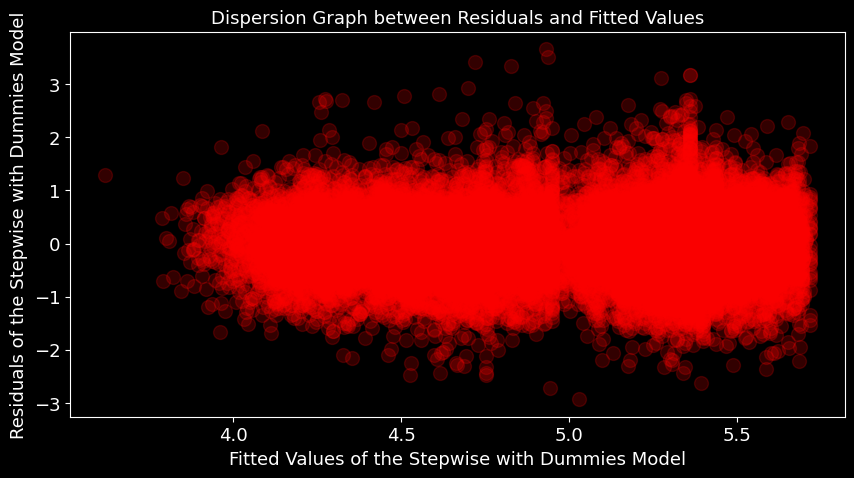

In [20]:
# plotting residuals x fitted values of the latter model
plt.figure(figsize=(10,5))
sns.regplot(x='fitted_step', y='residuals_step', data=saeb_df,
            marker='o', fit_reg=False,
            scatter_kws={"color":'red', 'alpha':0.2, 's':100})
plt.title('Dispersion Graph between Residuals and Fitted Values', fontsize=13)
plt.xlabel('Fitted Values of the Stepwise with Dummies Model', fontsize=13)
plt.ylabel('Residuals of the Stepwise with Dummies Model', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

# observe at the plot below that the heteroskedastic problem was mostly resolved, and only a small funnel shape persists, with
# Breusch-Pagan not able to reject H0, and thus we have a sufficiently homoskedastic model now.

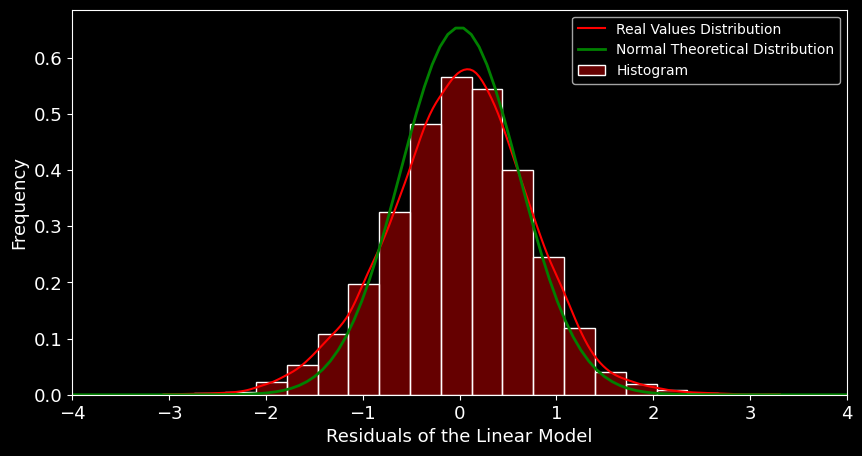

In [21]:
# Histogram of residuals distribution (from the model) x theoretical Normal distribution
# Kernel density estimation (KDE) - non-parametric form for estimation of density function probability of a certain variable

mu, sigma = norm.fit(saeb_dummies_step_model.resid)
plt.figure(figsize=(10,5))
sns.histplot(saeb_model.resid, bins=20, kde=True, stat="density",
             color='red', alpha=0.4)
plt.xlim(-4, 4)
x = np.linspace(-4, 4, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, color="green", linewidth=2)
plt.xlabel('Residuals of the Linear Model', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(['Real Values Distribution','Normal Theoretical Distribution','Histogram'],
           fontsize=10)
plt.show()

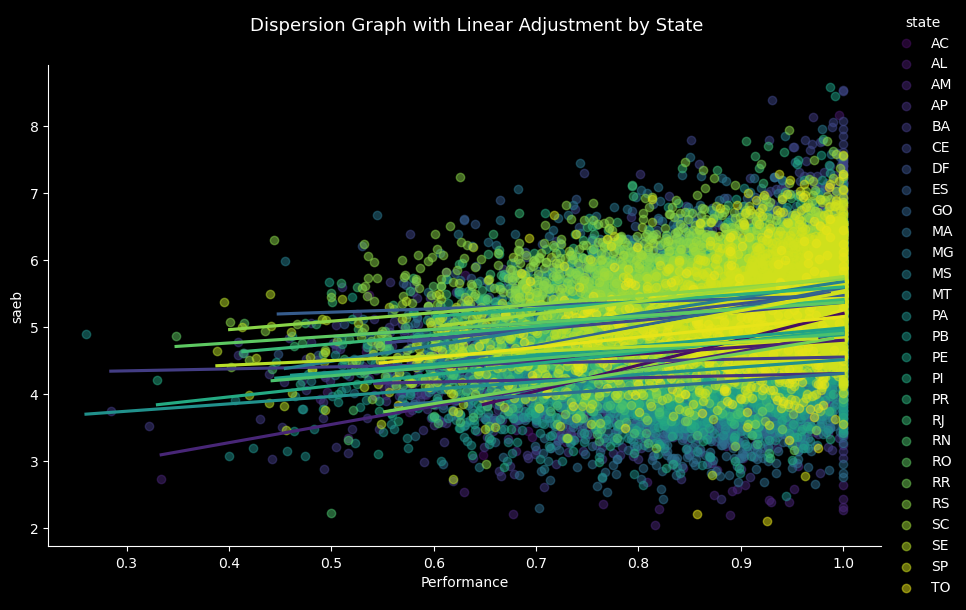

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

uf_order = saeb_df['state'].value_counts().index.sort_values()

# Create plot
g = sns.lmplot(
    x='performance',
    y='saeb',
    data=saeb_df,
    hue='state',
    ci=None,
    palette='viridis',
    scatter_kws={'alpha': 0.5},
    hue_order=uf_order,
    height=6,
    aspect=1.5
)

# Customize labels and title
g.set_axis_labels('Performance', 'saeb')
g.fig.suptitle('Dispersion Graph with Linear Adjustment by State', fontsize=13)

# Adjust title position
g.fig.subplots_adjust(top=0.9)

plt.show()